# TP5 — Apprentissage en ligne supervisé
**Perceptron · PA · OSD · Hedge · Kernels · Régularisation · Normes duales**

---
**Dataset** : Breast Cancer Wisconsin — classification binaire en ligne
**Dépendances** : `utils.py`, `perceptron.py`, `metrics.py`, `online_classifiers.py`, `hedge.py`, `kernels.py`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath('..'))
from utils import train_val_test_split, standardize, print_table, norm_l1, norm_l2, norm_linf, dual_norm
from TP2.perceptron import predict
from TP2.metrics import accuracy, f1_score, classification_report, plot_confusion_matrix, confusion_matrix
from online_classifiers import (
    perceptron_online, normalized_perceptron_online,
    passive_aggressive_online, compare_pa_variants, study_C_effect,
    osd_online, study_osd_steps, study_osd_regularization,
    compare_all_classifiers,
    plot_cumul_errors, plot_instant_losses_online,
    plot_w_norms, plot_sparsity, summary_table_classifiers
)
from hedge import (
    hedge, study_beta_effect,
    make_expert_losses_random, make_expert_losses_shifting, make_expert_losses_classification,
    plot_hedge_regret, plot_learner_vs_experts, plot_weights_evolution,
    plot_beta_comparison, hedge_summary
)
from kernels import (
    get_kernel, kernelized_perceptron, kernelized_perceptron_predict,
    kernelized_osd, kernelized_osd_predict, compare_kernels,
    plot_kernel_comparison, plot_cumul_errors_kernels,
    plot_support_growth, plot_decision_boundary_kernel
)
plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X_raw = data.data
y_raw = np.where(data.target == 1, 1, -1)
X_tr, y_tr, X_val, y_val, X_te, y_te = train_val_test_split(X_raw, y_raw, val_ratio=0.15, test_ratio=0.15, seed=SEED)
[X_tr_s, X_val_s, X_te_s], mu, std = standardize(X_tr, X_val, X_te)
print(f'Train: {len(y_tr)} | Val: {len(y_val)} | Test: {len(y_te)}')

Train: 399 | Val: 85 | Test: 85


---
## 1 · Normes et normes duales
**Questions ND.1 → ND.5**

In [3]:
w_test = np.array([1.0, -2.0, 3.0, -0.5])
print('w =', w_test)
print(f'||w||_1={norm_l1(w_test):.4f}  ||w||_2={norm_l2(w_test):.4f}  ||w||_inf={norm_linf(w_test):.4f}')
print(f'dual(l1)=||w||_inf={dual_norm(w_test,"l1"):.4f}')
print(f'dual(l2)=||w||_2  ={dual_norm(w_test,"l2"):.4f}')
print(f'dual(linf)=||w||_1={dual_norm(w_test,"linf"):.4f}')
print('Borne RT <= ||u||^2/(2eta) + (eta/2)*sum||gt||^2_*')
print('  => choisir eta = ||u|| / (||g||_* * sqrt(T))')

w = [ 1.  -2.   3.  -0.5]
||w||_1=6.5000  ||w||_2=3.7749  ||w||_inf=3.0000
dual(l1)=||w||_inf=3.0000
dual(l2)=||w||_2  =3.7749
dual(linf)=||w||_1=6.5000
Borne RT <= ||u||^2/(2eta) + (eta/2)*sum||gt||^2_*
  => choisir eta = ||u|| / (||g||_* * sqrt(T))


---
## 2 · Perceptron standard et Normalized Perceptron
**Questions P.1→P.5, NP.1→NP.4**

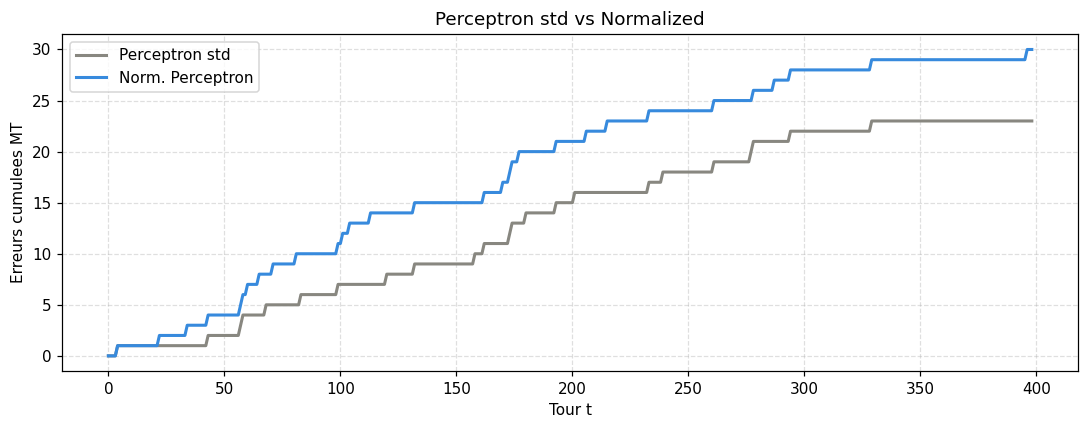

Acc test std     : 0.9294
Acc test norm    : 0.9529


In [4]:
w_p,  b_p,  hist_p  = perceptron_online(X_tr_s, y_tr)
w_np, b_np, hist_np = normalized_perceptron_online(X_tr_s, y_tr)
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(hist_p['cumul_errors'],  label='Perceptron std',   color='#888780', linewidth=2)
ax.plot(hist_np['cumul_errors'], label='Norm. Perceptron', color='#378ADD', linewidth=2)
ax.set_xlabel('Tour t'); ax.set_ylabel('Erreurs cumulees MT')
ax.set_title('Perceptron std vs Normalized'); ax.legend(); ax.grid(True,linestyle='--',alpha=0.4)
plt.tight_layout(); plt.savefig('../outputs/figures/TP5_02_perceptron.png',bbox_inches='tight'); plt.show()
print(f'Acc test std     : {accuracy(y_te, predict(w_p, b_p, X_te_s)):.4f}')
print(f'Acc test norm    : {accuracy(y_te, predict(w_np,b_np,X_te_s)):.4f}')

---
## 3 · Passive-Aggressive : PA, PA-I, PA-II
**Questions PA.1 → PA.5**

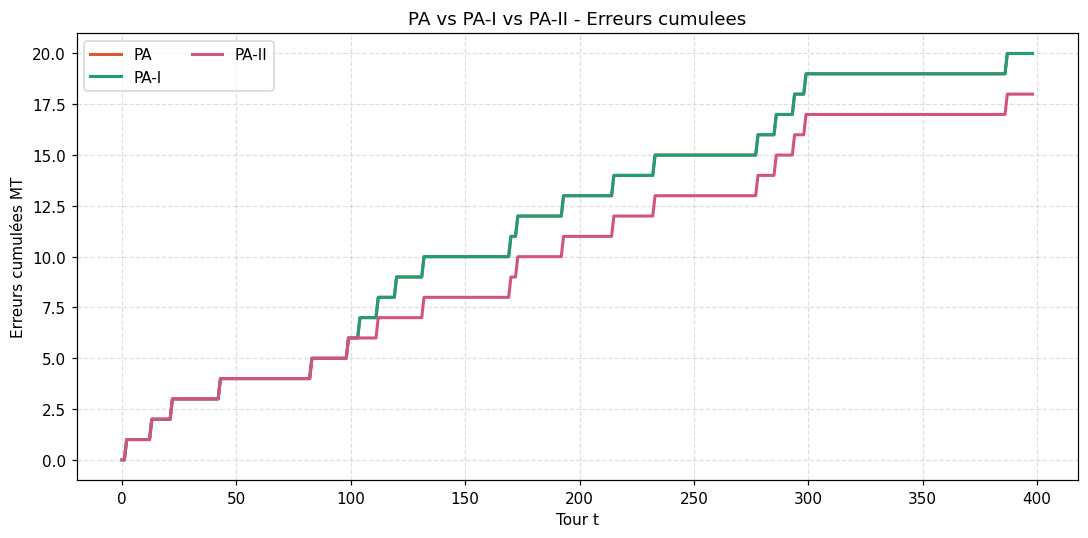

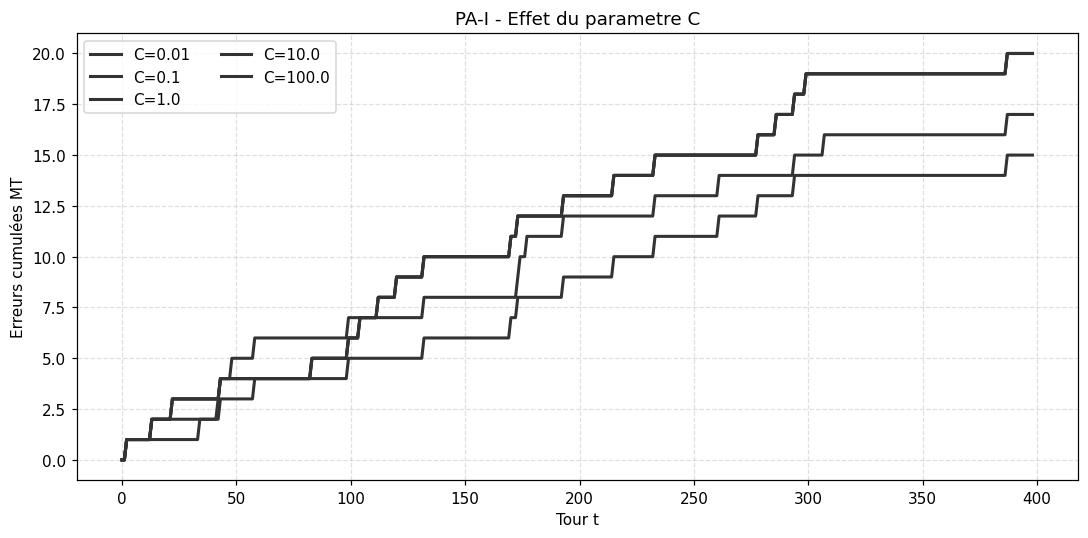

C        Acc.Test  F1 Test  Err.
-------  --------  -------  ----
C=0.01   0.9882    0.9913   17  
C=0.1    0.9882    0.9913   15  
C=1.0    0.9882    0.9913   20  
C=10.0   0.9882    0.9913   20  
C=100.0  0.9882    0.9913   20  


In [5]:
results_pa = compare_pa_variants(X_tr_s, y_tr, C=1.0)
fig = plot_cumul_errors(results_pa, title='PA vs PA-I vs PA-II - Erreurs cumulees')
plt.savefig('../outputs/figures/TP5_03_pa_variants.png',bbox_inches='tight'); plt.show()
results_C = study_C_effect(X_tr_s, y_tr, C_values=[0.01,0.1,1.0,10.0,100.0], variant='PA-I')
fig = plot_cumul_errors(results_C, title='PA-I - Effet du parametre C')
plt.savefig('../outputs/figures/TP5_04_pa_C.png',bbox_inches='tight'); plt.show()
headers=['C','Acc.Test','F1 Test','Err.']
table=[[lbl, f'{accuracy(y_te,predict(w,b,X_te_s)):.4f}', f'{f1_score(y_te,predict(w,b,X_te_s)):.4f}', str(h["cumul_errors"][-1])] for lbl,(w,b,h) in results_C.items()]
print_table(table, headers)

---
## 4 · OSD + Regularisation en ligne
**Questions OSD.1→OSD.5, REG.1→REG.7**

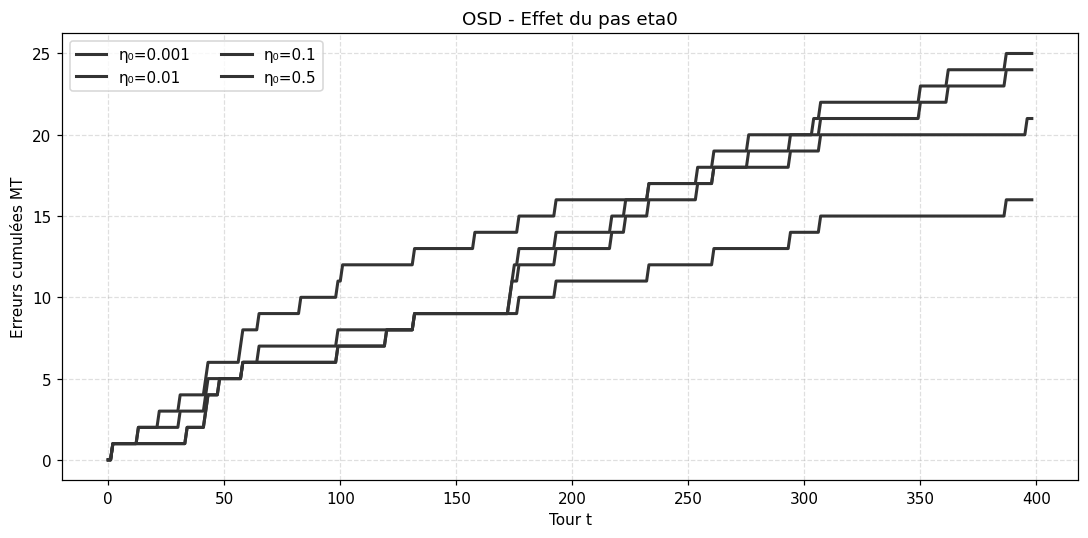

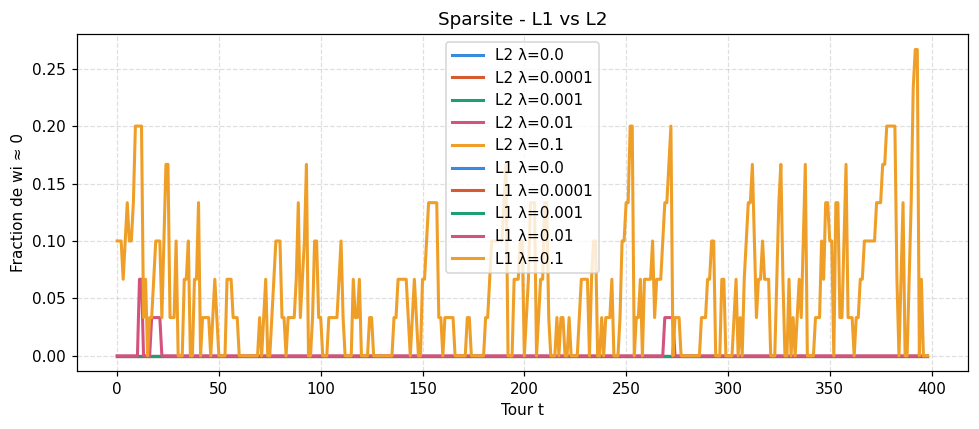

L1 favorise la sparsite (beaucoup de wi=0), L2 reduit la norme sans annuler.


In [6]:
results_osd_steps = study_osd_steps(X_tr_s, y_tr, eta0_values=[0.001,0.01,0.1,0.5])
fig = plot_cumul_errors(results_osd_steps, title='OSD - Effet du pas eta0')
plt.savefig('../outputs/figures/TP5_05_osd_steps.png',bbox_inches='tight'); plt.show()
results_l2 = study_osd_regularization(X_tr_s, y_tr, lambdas=[0.0,1e-4,1e-3,1e-2,0.1], reg='l2')
results_l1 = study_osd_regularization(X_tr_s, y_tr, lambdas=[0.0,1e-4,1e-3,1e-2,0.1], reg='l1')
fig = plot_sparsity({**{f'L2 {k}':v for k,v in results_l2.items()}, **{f'L1 {k}':v for k,v in results_l1.items()}}, title='Sparsite - L1 vs L2')
plt.savefig('../outputs/figures/TP5_06_sparsity.png',bbox_inches='tight'); plt.show()
print('L1 favorise la sparsite (beaucoup de wi=0), L2 reduit la norme sans annuler.')

---
## 5 · Comparaison de tous les classificateurs
**Questions T.1 → T.3**

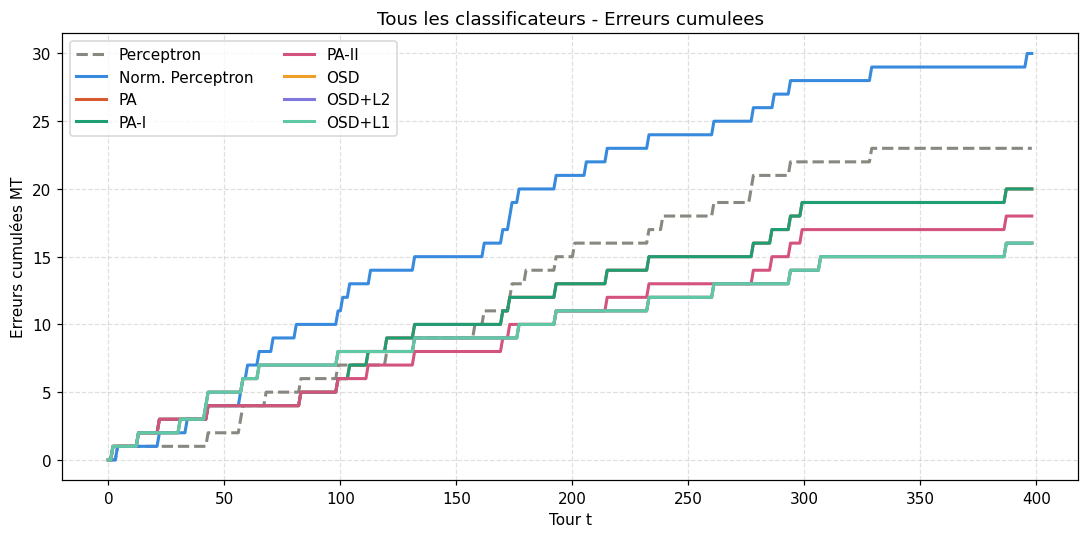

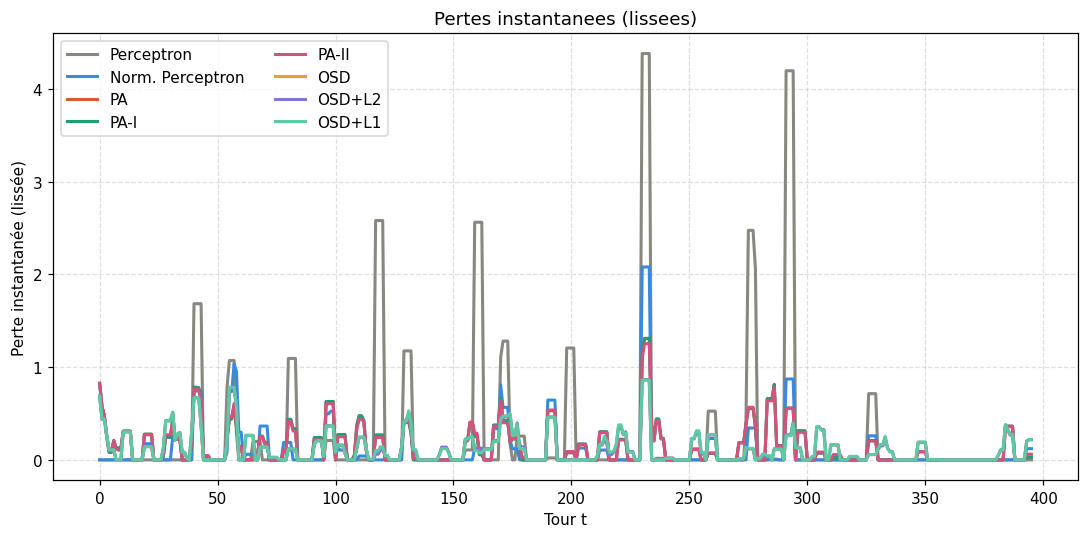

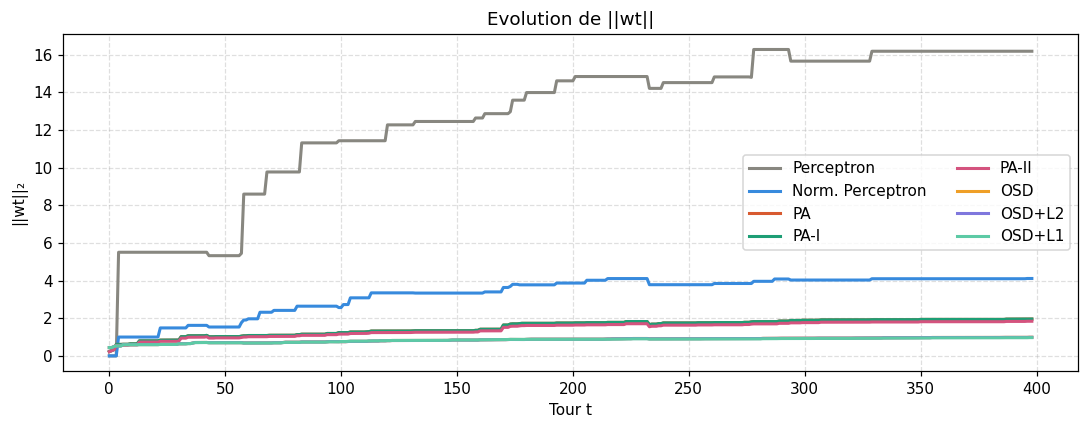


Algorithme            Err. cum.     Acc.       F1    ||w||   Sparsité
----------------------------------------------------------------------
Perceptron                   23   0.9294   0.9483   16.176      0.000
Norm. Perceptron             30   0.9529   0.9661    4.109      0.000
PA                           20   0.9882   0.9913    1.956      0.000
PA-I                         20   0.9882   0.9913    1.956      0.000
PA-II                        18   0.9882   0.9913    1.838      0.000
OSD                          16   0.9765   0.9828    0.991      0.000
OSD+L2                       16   0.9765   0.9828    0.988      0.000
OSD+L1                       16   0.9765   0.9828    0.970      0.000


In [7]:
results_all = compare_all_classifiers(X_tr_s, y_tr, eta0=0.1, C=1.0)
fig = plot_cumul_errors(results_all, title='Tous les classificateurs - Erreurs cumulees')
plt.savefig('../outputs/figures/TP5_07_all_errors.png',bbox_inches='tight'); plt.show()
fig = plot_instant_losses_online(results_all, title='Pertes instantanees (lissees)')
plt.savefig('../outputs/figures/TP5_08_all_losses.png',bbox_inches='tight'); plt.show()
fig = plot_w_norms(results_all, title='Evolution de ||wt||')
plt.savefig('../outputs/figures/TP5_09_w_norms.png',bbox_inches='tight'); plt.show()
summary_table_classifiers(results_all, X_te_s, y_te)

---
## 6 · Hedge — Prediction with Expert Advice
**Questions H.1 → H.5**

  Résumé — Hedge (3 experts)
  Perte cumulée apprenant : 255.7150
  Perte meilleur expert   : 249.1287
  Regret final            : 6.5863
  Meilleur expert         : Expert 3


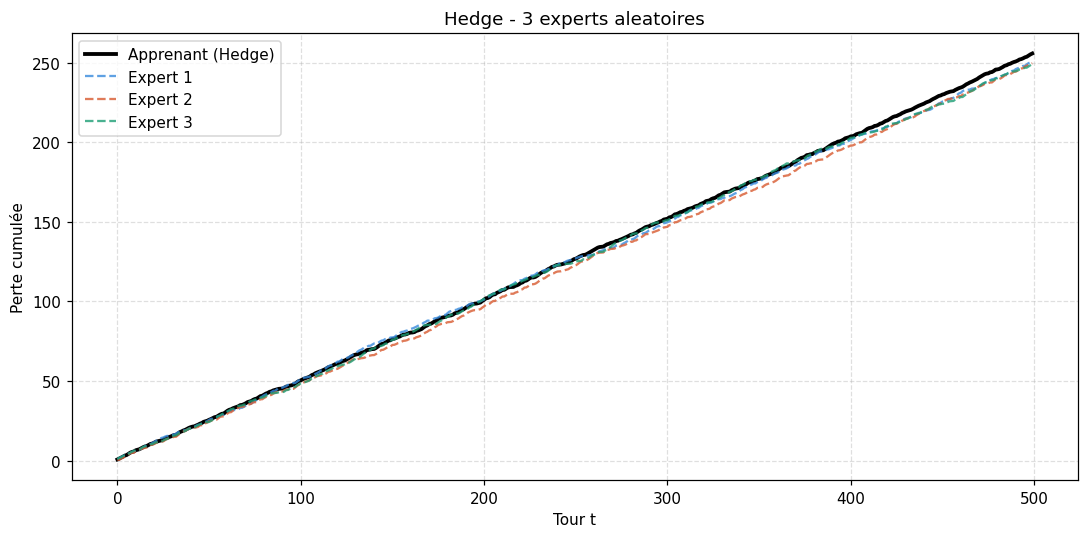

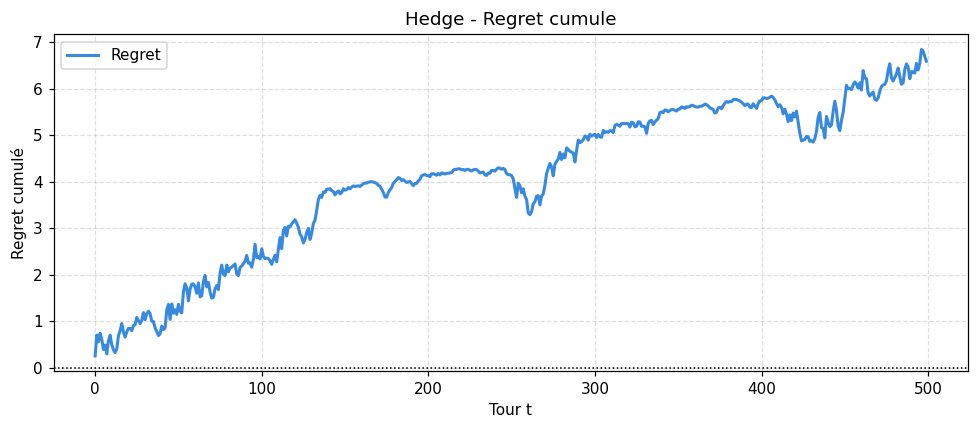

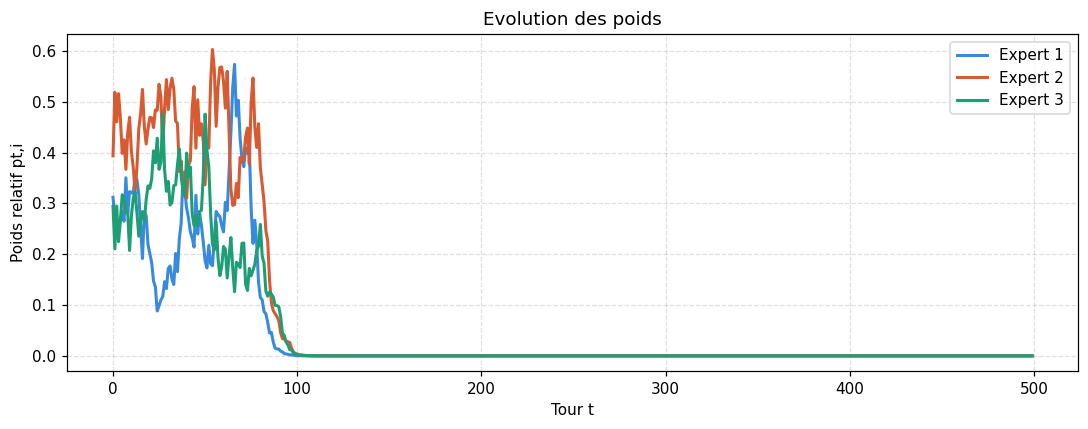

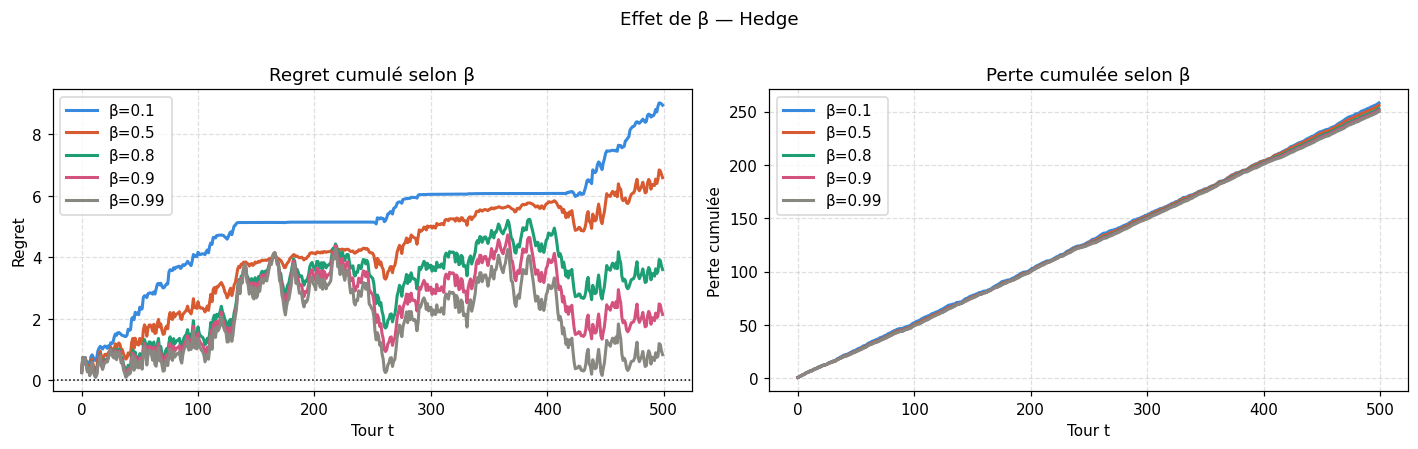

In [8]:
losses_rand = make_expert_losses_random(T=500, N=3, seed=SEED)
hist_h = hedge(losses_rand, beta=0.5)
hedge_summary(hist_h, 3)
fig = plot_learner_vs_experts(hist_h, title='Hedge - 3 experts aleatoires')
plt.savefig('../outputs/figures/TP5_10_hedge.png',bbox_inches='tight'); plt.show()
fig = plot_hedge_regret(hist_h, title='Hedge - Regret cumule')
plt.savefig('../outputs/figures/TP5_11_hedge_regret.png',bbox_inches='tight'); plt.show()
fig = plot_weights_evolution(hist_h, title='Evolution des poids')
plt.savefig('../outputs/figures/TP5_12_hedge_weights.png',bbox_inches='tight'); plt.show()
results_beta = study_beta_effect(losses_rand, betas=[0.1,0.5,0.8,0.9,0.99])
fig = plot_beta_comparison(results_beta)
plt.savefig('../outputs/figures/TP5_13_hedge_beta.png',bbox_inches='tight'); plt.show()

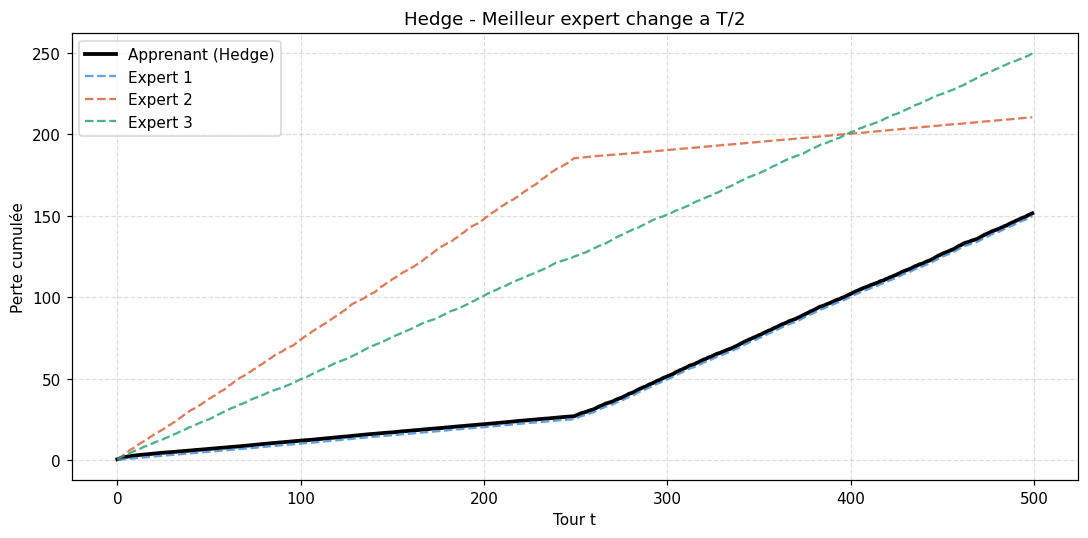

  Résumé — Hedge (3 experts)
  Perte cumulée apprenant : 9.4302
  Perte meilleur expert   : 6.0000
  Regret final            : 3.4302
  Meilleur expert         : Expert 3


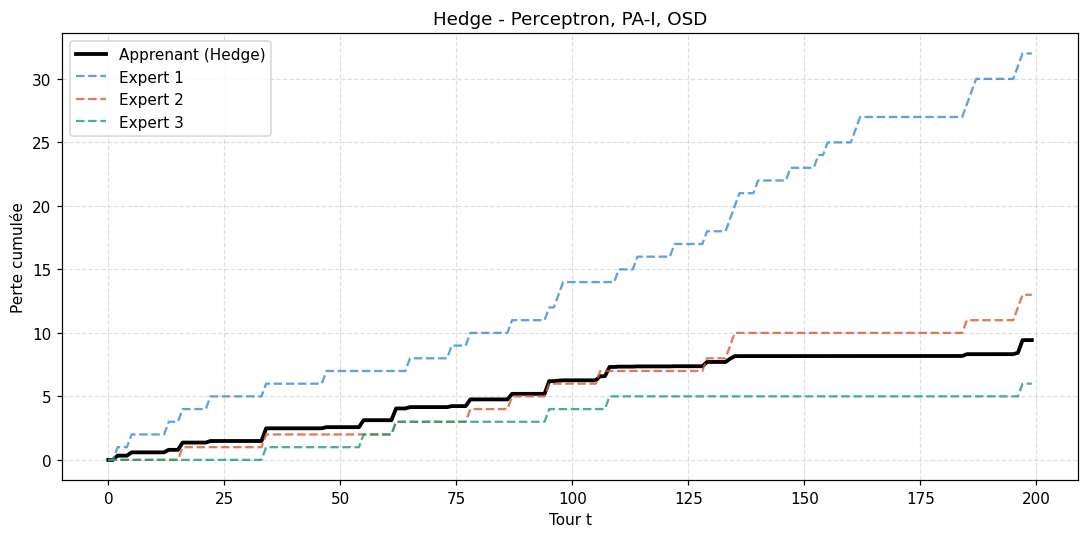

In [9]:
# Experts changeants
losses_shift = make_expert_losses_shifting(T=500, N=3, seed=SEED)
hist_shift = hedge(losses_shift, beta=0.5)
fig = plot_learner_vs_experts(hist_shift, title='Hedge - Meilleur expert change a T/2')
plt.savefig('../outputs/figures/TP5_14_hedge_shift.png',bbox_inches='tight'); plt.show()
# Vrais classificateurs comme experts
half = len(y_tr)//2
w1,b1,_ = perceptron_online(X_tr_s[:half], y_tr[:half])
w2,b2,_ = passive_aggressive_online(X_tr_s[:half], y_tr[:half], C=1.0, variant='PA-I')
w3,b3,_ = osd_online(X_tr_s[:half], y_tr[:half], eta0=0.1, decay='sqrt')
losses_clf = make_expert_losses_classification(X_tr_s[half:], y_tr[half:], [(w1,b1),(w2,b2),(w3,b3)])
hist_clf_h = hedge(losses_clf, beta=0.7)
hedge_summary(hist_clf_h, 3)
fig = plot_learner_vs_experts(hist_clf_h, title='Hedge - Perceptron, PA-I, OSD')
plt.savefig('../outputs/figures/TP5_15_hedge_clf.png',bbox_inches='tight'); plt.show()

---
## 7 · Online Learning with Kernels
**Questions K.1 → K.6**

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=SEED)
X_tr_2d = pca.fit_transform(X_tr); X_te_2d = pca.transform(X_te)
[X_tr_2d_s, X_te_2d_s], _, _ = standardize(X_tr_2d, X_te_2d)
print(f'2D Train: {X_tr_2d_s.shape}')

2D Train: (399, 2)


Lineaire — Acc: 0.9059, SV: 39
Gaussien — Acc: 0.8118, SV: 44


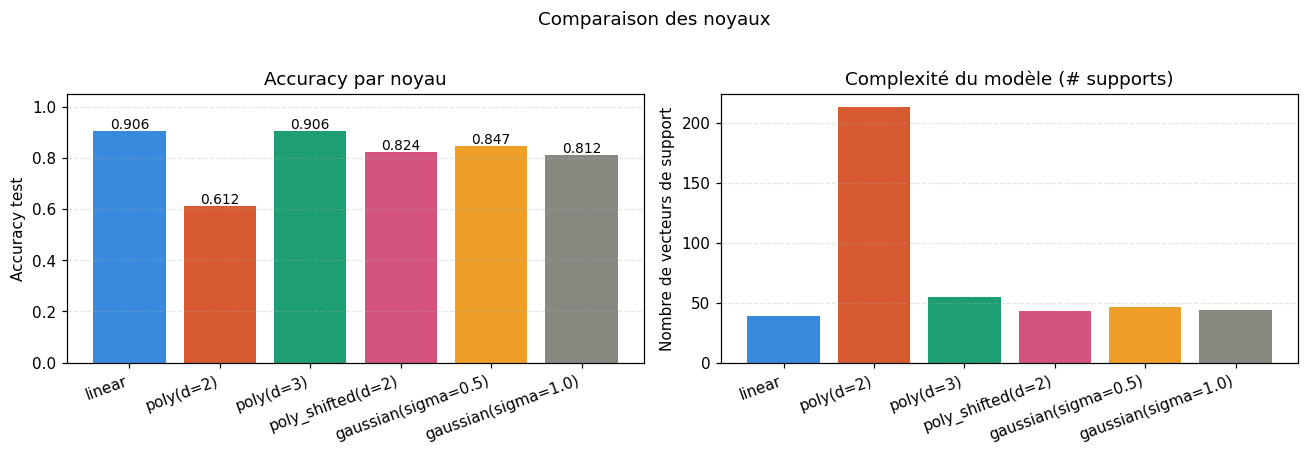

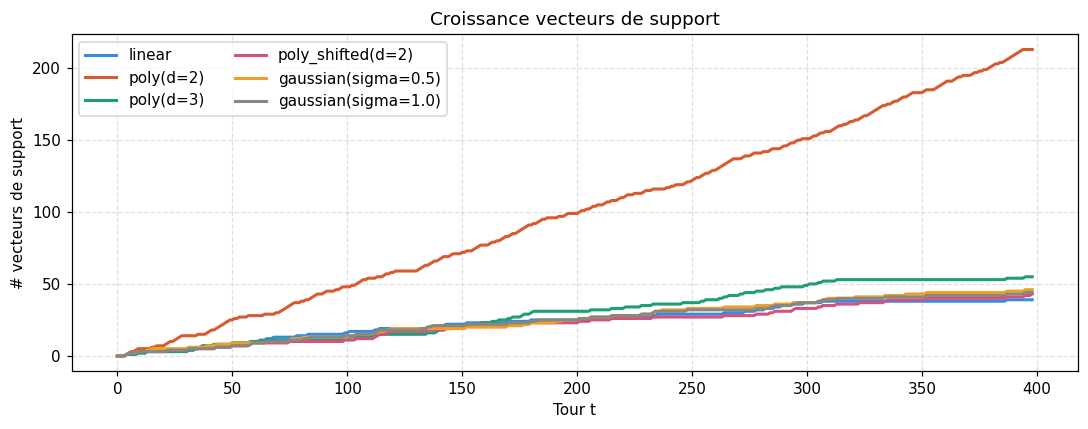

In [11]:
# K.1 - Perceptron kernelise
kfn_lin = get_kernel('linear')
sv_lin, alp_lin, hist_kl = kernelized_perceptron(X_tr_2d_s, y_tr, kfn_lin)
print(f'Lineaire — Acc: {accuracy(y_te, kernelized_perceptron_predict(sv_lin,alp_lin,kfn_lin,X_te_2d_s)):.4f}, SV: {len(sv_lin)}')
kfn_rbf = get_kernel('gaussian', sigma=1.0)
sv_rbf, alp_rbf, hist_kr = kernelized_perceptron(X_tr_2d_s, y_tr, kfn_rbf)
print(f'Gaussien — Acc: {accuracy(y_te, kernelized_perceptron_predict(sv_rbf,alp_rbf,kfn_rbf,X_te_2d_s)):.4f}, SV: {len(sv_rbf)}')
# K.3 - Comparaison noyaux
kcfgs=[{'name':'linear'},{'name':'poly','d':2},{'name':'poly','d':3},{'name':'poly_shifted','d':2},{'name':'gaussian','sigma':0.5},{'name':'gaussian','sigma':1.0}]
results_kernels = compare_kernels(X_tr_2d_s, y_tr, X_te_2d_s, y_te, kernel_configs=kcfgs)
fig = plot_kernel_comparison(results_kernels, title='Comparaison des noyaux')
plt.savefig('../outputs/figures/TP5_16_kernels.png',bbox_inches='tight'); plt.show()
fig = plot_support_growth(results_kernels, title='Croissance vecteurs de support')
plt.savefig('../outputs/figures/TP5_17_support.png',bbox_inches='tight'); plt.show()

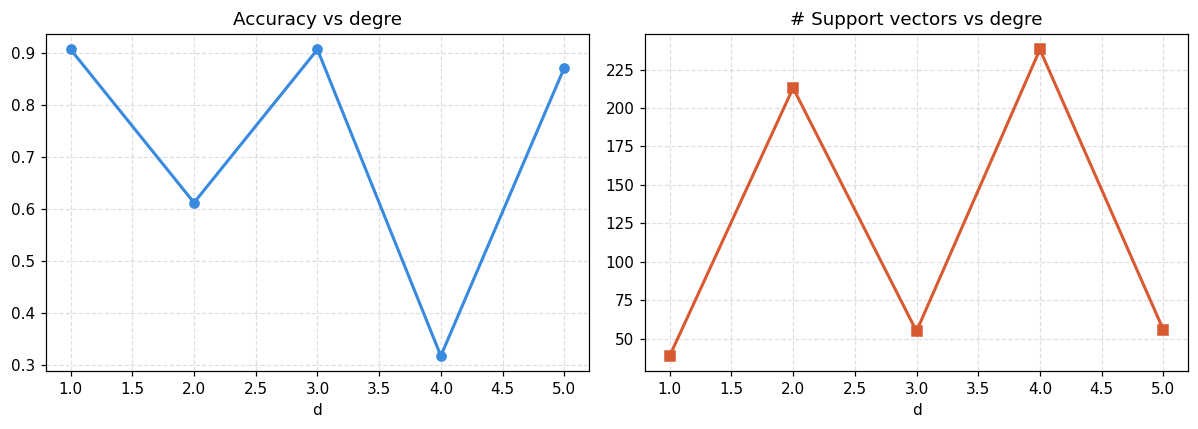

In [12]:
# K.4 - Effet du degre poly
poly_cfgs=[{'name':'poly','d':d} for d in [1,2,3,4,5]]
res_poly = compare_kernels(X_tr_2d_s, y_tr, X_te_2d_s, y_te, kernel_configs=poly_cfgs)
degrees=[1,2,3,4,5]
accs=[res_poly.get(f'poly(d={d})',res_poly.get(f'poly',{'accuracy':0}))['accuracy'] for d in degrees]
n_svs=[res_poly.get(f'poly(d={d})',res_poly.get(f'poly',{'n_support':0}))['n_support'] for d in degrees]
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(degrees,accs,marker='o',color='#378ADD',linewidth=2); axes[0].set_title('Accuracy vs degre'); axes[0].set_xlabel('d'); axes[0].grid(True,linestyle='--',alpha=0.4)
axes[1].plot(degrees,n_svs,marker='s',color='#D85A30',linewidth=2); axes[1].set_title('# Support vectors vs degre'); axes[1].set_xlabel('d'); axes[1].grid(True,linestyle='--',alpha=0.4)
plt.tight_layout(); plt.savefig('../outputs/figures/TP5_18_poly_deg.png',bbox_inches='tight'); plt.show()

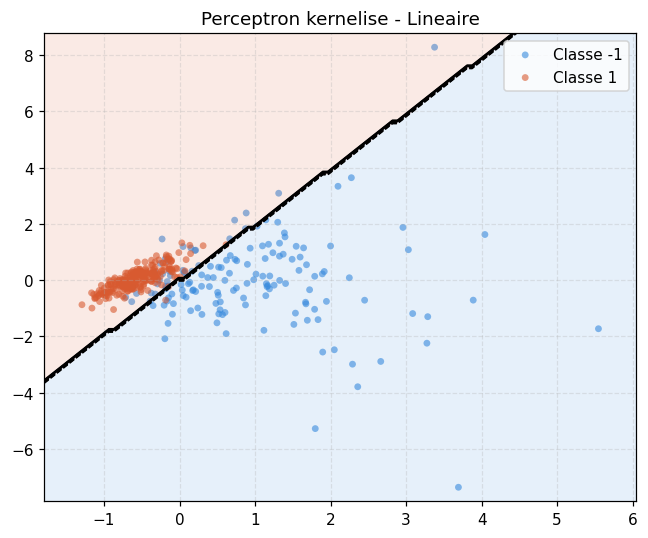

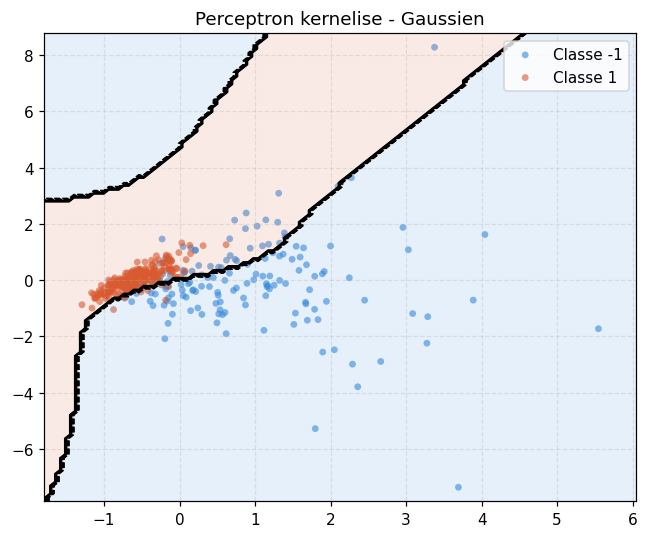

In [13]:
# K.6 - Frontieres de decision
for kname, sv, alp in [('Lineaire',sv_lin,alp_lin),('Gaussien',sv_rbf,alp_rbf)]:
    kfn = get_kernel('linear') if kname=='Lineaire' else get_kernel('gaussian',sigma=1.0)
    fig = plot_decision_boundary_kernel(sv, alp, kfn, X_tr_2d_s, y_tr, title=f'Perceptron kernelise - {kname}')
    plt.savefig(f'../outputs/figures/TP5_19_{kname.lower()}.png',bbox_inches='tight'); plt.show()

---
## 8 · Validation et choix des hyperparametres
**Questions VAL.1→VAL.5**

In [14]:
eta0_cands=[0.001,0.01,0.05,0.1,0.5]
val_accs=[accuracy(y_val, predict(*osd_online(X_tr_s,y_tr,eta0=e,decay='sqrt')[:2], X_val_s)) for e in eta0_cands]
best_eta0=eta0_cands[int(np.argmax(val_accs))]
for e,a in zip(eta0_cands, val_accs):
    print(f'eta0={e:.3f} -> val acc={a:.4f}{" <-- meilleur" if e==best_eta0 else ""}')
w_f,b_f,_=osd_online(X_tr_s,y_tr,eta0=best_eta0,decay='sqrt')
print(f'\nAcc. test final (eta0={best_eta0}): {accuracy(y_te,predict(w_f,b_f,X_te_s)):.4f}')

eta0=0.001 -> val acc=0.8941
eta0=0.010 -> val acc=0.9059
eta0=0.050 -> val acc=0.9647
eta0=0.100 -> val acc=0.9647
eta0=0.500 -> val acc=0.9765 <-- meilleur

Acc. test final (eta0=0.5): 0.9647


---
## 9 · Conclusion

In [15]:
print('='*60)
print('SYNTHESE TP5')
print('='*60)
summary_table_classifiers(results_all, X_te_s, y_te)
print('\nConclusions :')
print('- Perceptron : simple, garanti mais lent')
print('- PA-II : meilleur compromis passif/agressif')
print('- OSD+L1 : sparsite, OSD+L2 : stabilite')
print('- Hedge : robuste aux changements de distribution')
print('- Noyau gaussien ameliore les frontieres non lineaires')
print('- Normes duales dans les bornes de regret : ||u||^2 / eta + eta/2 * sum ||gt||^2_*')

SYNTHESE TP5

Algorithme            Err. cum.     Acc.       F1    ||w||   Sparsité
----------------------------------------------------------------------
Perceptron                   23   0.9294   0.9483   16.176      0.000
Norm. Perceptron             30   0.9529   0.9661    4.109      0.000
PA                           20   0.9882   0.9913    1.956      0.000
PA-I                         20   0.9882   0.9913    1.956      0.000
PA-II                        18   0.9882   0.9913    1.838      0.000
OSD                          16   0.9765   0.9828    0.991      0.000
OSD+L2                       16   0.9765   0.9828    0.988      0.000
OSD+L1                       16   0.9765   0.9828    0.970      0.000

Conclusions :
- Perceptron : simple, garanti mais lent
- PA-II : meilleur compromis passif/agressif
- OSD+L1 : sparsite, OSD+L2 : stabilite
- Hedge : robuste aux changements de distribution
- Noyau gaussien ameliore les frontieres non lineaires
- Normes duales dans les bornes de regr